In [1]:
# SARA SOFÍA GÓMEZ SUÁREZ • TALLER 16 DE ABRIL

In [2]:
# PRIMER PROBLEMA: MEZCLA DE FERTILIZANTES
import numpy as np
from scipy.optimize import linprog

# COEFICIENTES DE LA FUNCIÓN OBJETIVO
# NEGATIVOS PORQUE LINPROG MINIMIZA Y QUEREMOS MAXIMIZAR
c = [-180, -220]

# COEFICIENTES DE LAS RESTRICCIONES
A = [
    [3, 4],   # Compuesto A
    [2, 1],   # Compuesto B
    [5, 3]    # Compuesto C
]

# LADO DERECHO DE LAS RESTRICCIONES
b = [120, 80, 150]

# RESTRICCIONES DE NO NEGATIVIDAD
x_bounds = [(0, None), (0, None)]

# SOLUCIÓN
resultado = linprog(c, A_ub=A, b_ub=b, bounds=x_bounds, method='highs')

# RESULTADOS

print("Solución óptima encontrada:")
print(f"F1 (Fertilizante 1) = {resultado.x[0]:.2f}")
print(f"F2 (Fertilizante 2) = {resultado.x[1]:.2f}")
print(f"Ganancia máxima = ${-resultado.fun:.2f}")

Solución óptima encontrada:
F1 (Fertilizante 1) = 21.82
F2 (Fertilizante 2) = 13.64
Ganancia máxima = $6927.27


In [3]:
# SEGUNDO PROBLEMA: PRODUCCIÓN SEMANAL DE UNA FÁBRICA


# ECUACIONES INICIALES
def produccion_siguiente(S_n, M_n):
    S_nmas1 = 0.6 * S_n + 0.2 * M_n + 40
    M_nmas1 = 0.1 * S_n + 0.5 * M_n + 20
    return S_nmas1, M_nmas1

# CONDICIONES INICIALES
S0 = 200
M0 = 80
n_simular = 2  # SEMANAS A CALCULAR

S = [S0]
M = [M0]

# SIMULACIÓN
for i in range(n_simular):
    S_nmas1, M_nmas1 = produccion_siguiente(S[i], M[i])

    S.append(S_nmas1)
    M.append(M_nmas1)

# Resultado
print ("PRODUCCIÓN SEMANAS 1 Y 2")
print ()

for i in range(len(S)):
    print (f"Semana {i}  Sillas = {S[i]:6.2f}    Mesas = {M[i]:6.2f}")


PRODUCCIÓN SEMANAS 1 Y 2

Semana 0  Sillas = 200.00    Mesas =  80.00
Semana 1  Sillas = 176.00    Mesas =  80.00
Semana 2  Sillas = 161.60    Mesas =  77.60


Infectados iniciales: 50.00
Infectados al final (t = 100 días): 6666.67


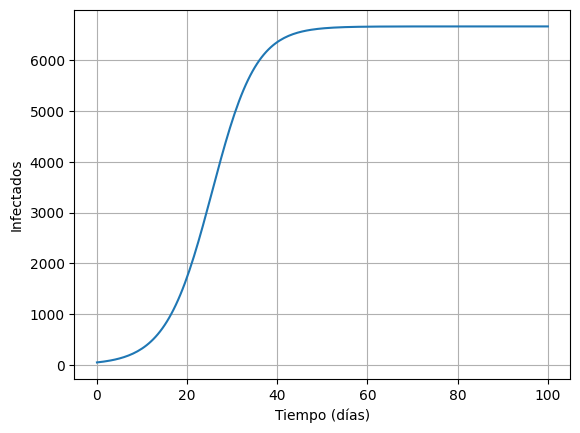

In [4]:
# TERCER PROBLEMA: EPIDEMIA EN UNA CIUDAD

import numpy as np
import matplotlib.pyplot as plt

# PARÁMETROS
beta = 0.00003
gamma = 0.1

# FUNCIÓN DEL MODELO
def f(I):
    return beta * (10000 - I) * I - gamma * I

t0 = 0
tf = 100
h = 0.5

# VECTOR DE TIEMPO
t = np.arange(t0, tf + h, h)

# SOLUCIÓN
I = np.zeros(len(t))
I[0] = 50 # CONDICIÓN INICIAL

for i in range(len(t) - 1):
    I[i+1] = I[i] + h * f(I[i])

#RESULTADOS
print(f"Infectados iniciales: {I[0]:.2f}")
print(f"Infectados al final (t = {tf} días): {I[-1]:.2f}")

# GRÁFICA
plt.plot(t, I)
plt.xlabel("Tiempo (días)")
plt.ylabel("Infectados")
plt.grid()
plt.show()

In [7]:
# CUARTO PROBLEMA: MODELO LOGÍSTICO DE PESCA

# PARÁMETROS
r = 0.4
K = 1000
H = 80

# NÚMERO DE AÑOS
n_years = 2

# CONDICIONES INICIALES
P = np.zeros(n_years + 1)
P[0] = 400

# MODELO
for n in range(n_years):
    P[n+1] = P[n] + r * P[n] * (1 - P[n]/K) - H

# RESULTADOS

print(f"Población inicial: {P[0]:.2f}")
print(f"P1 (año 1): {P[1]:.2f}")
print(f"P2 (año 2): {P[2]:.2f}")


Población inicial: 400.00
P1 (año 1): 416.00
P2 (año 2): 433.18
